# Task 1 — Pre-processing of 10X Single-Cell RNA Datasets

**Reference:** [Galaxy Project scRNA-seq Pre-processing Tutorial](https://training.galaxyproject.org/training-material/topics/single-cell/tutorials/scrna-preprocessing-tenx/tutorial.html)

**Dataset:** PBMC 3K (10X Genomics)  
**Tools:** Scanpy, AnnData, Matplotlib

---

## Step 0 — Install & Import Libraries

In [4]:
# Install required libraries (run this in Colab)
# !pip install scanpy matplotlib seaborn
!pip install scanpy
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sc.settings.verbosity = 3             # show progress
sc.settings.set_figure_params(dpi=80, facecolor='white', figsize=(6, 4))

print('Scanpy version:', sc.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 46.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2

## Step 1 — Load the 10X PBMC 3K Dataset

In [5]:
# Load PBMC 3K dataset (Scanpy built-in)
adata = sc.datasets.pbmc3k()

print('AnnData object:')
print(adata)
print(f'\nShape: {adata.shape[0]} cells × {adata.shape[1]} genes')

try downloading from url
https://exampledata.scverse.org/scanpy/pbmc3k_raw.h5ad
... this may take a while but only happens once


  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object:
AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

Shape: 2700 cells × 32738 genes


## Step 2 — Calculate Quality Control Metrics

This code calculates key quality control (QC) metrics by identifying mitochondrial genes and quantifying library size and gene counts for each cell. These statistics are used to filter out low-quality cells, such as those that are damaged or dying, ensuring your downstream analysis relies only on robust, high-quality biological data.

In [6]:
# Identify mitochondrial genes (gene names starting with 'MT-')
adata.var['mt'] = adata.var_names.str.startswith('MT-')
print(f'Number of mitochondrial genes: {adata.var["mt"].sum()}')

# Calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['mt'],
    percent_top=None,
    log1p=False,
    inplace=True
)

print('\nQC metrics added to adata.obs:')
print(adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].describe().round(2))

Number of mitochondrial genes: 13

QC metrics added to adata.obs:
       n_genes_by_counts  total_counts  pct_counts_mt
count            2700.00       2700.00        2700.00
mean              846.99       2366.90           2.22
std               282.10       1094.26           1.17
min               212.00        548.00           0.00
25%               690.00       1757.75           1.54
50%               817.00       2197.00           2.03
75%               953.25       2763.00           2.64
max              3422.00      15844.00          22.57


## Step 3 — QC Visualization

This code creates a multi-panel violin plot to visualize the distribution of essential quality control metrics across all cells, helping you identify potential outliers. The jitter parameter adds individual cell points to the plot, making it easier to spot subpopulations or clusters of low-quality cells that might need to be filtered out.

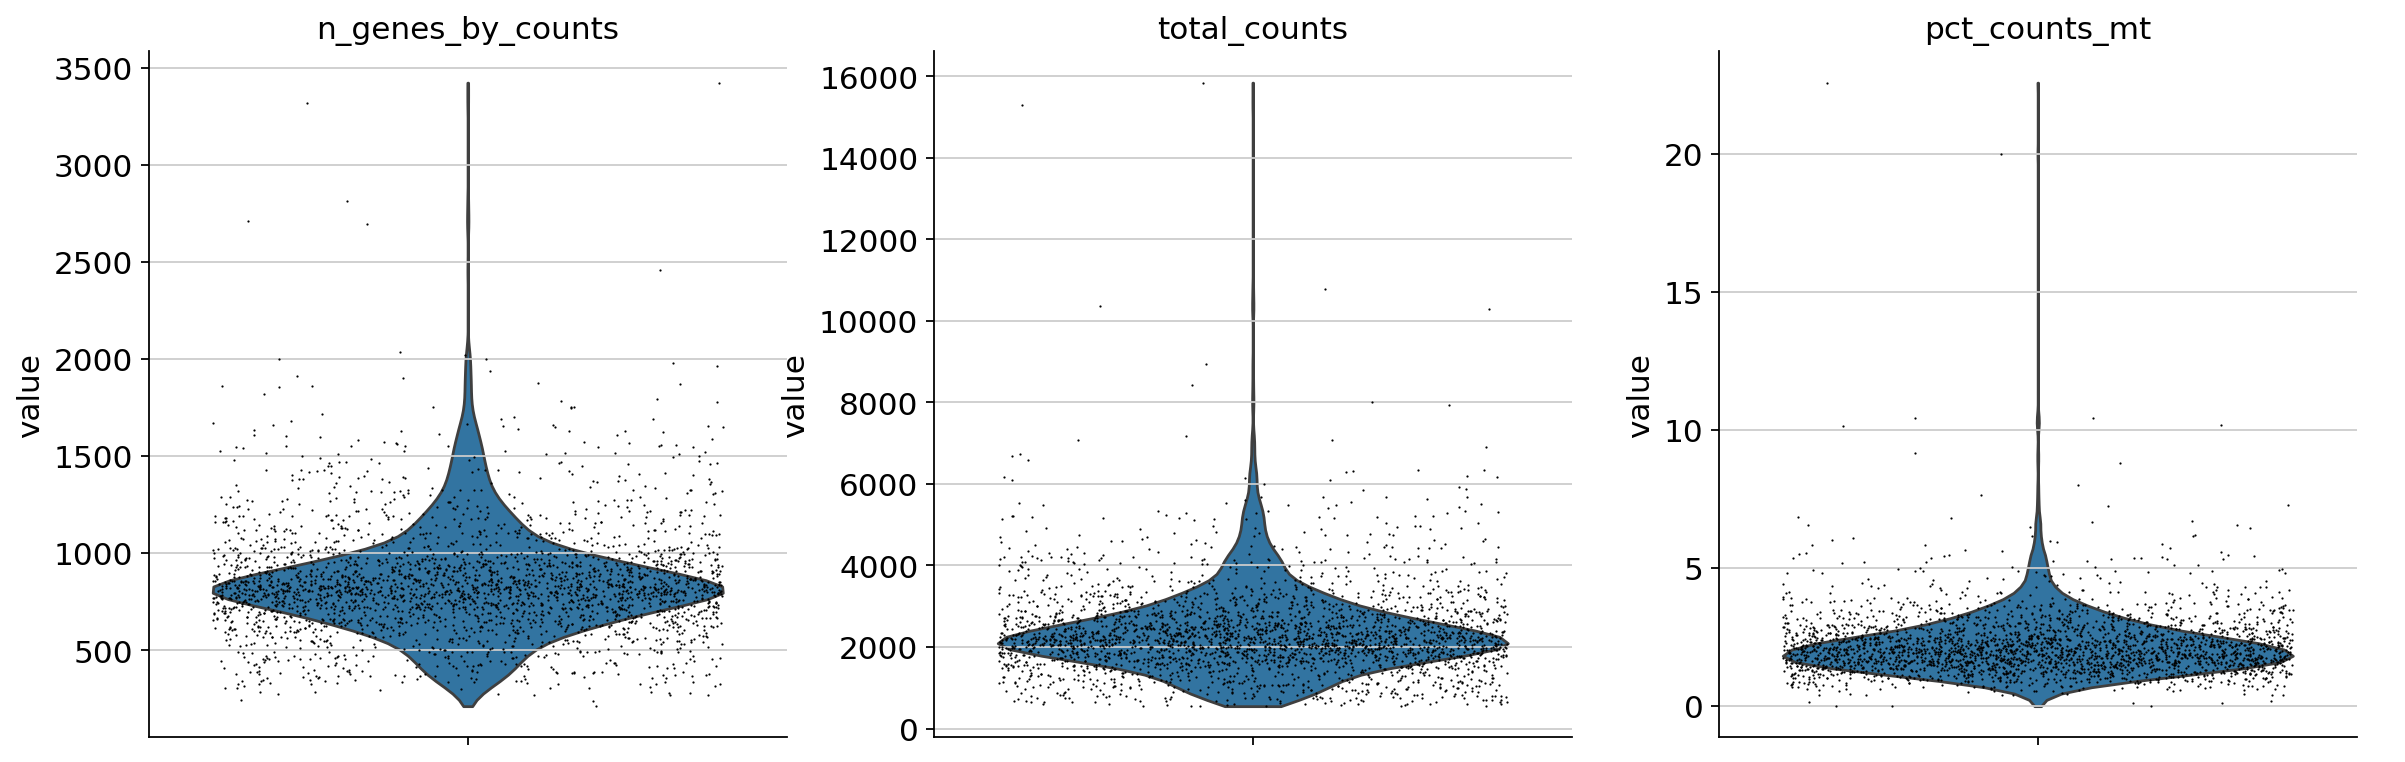

QC violin plot saved.


In [7]:
# Violin plots of QC metrics
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True,
    save='_qc_violin.png'
)
print('QC violin plot saved.')

This code generates scatter plots to visualize the relationship between total library size, gene counts, and mitochondrial percentage, which helps in setting informed QC thresholds. By inspecting these plots, you can easily identify cells with abnormally low total counts or high mitochondrial percentages, which are common indicators of technical noise or poor-quality cells.

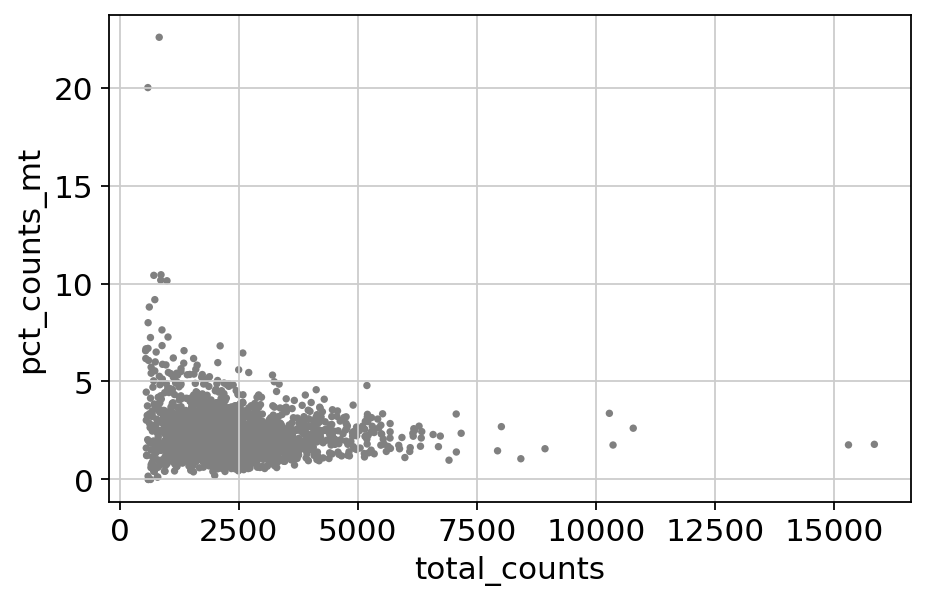

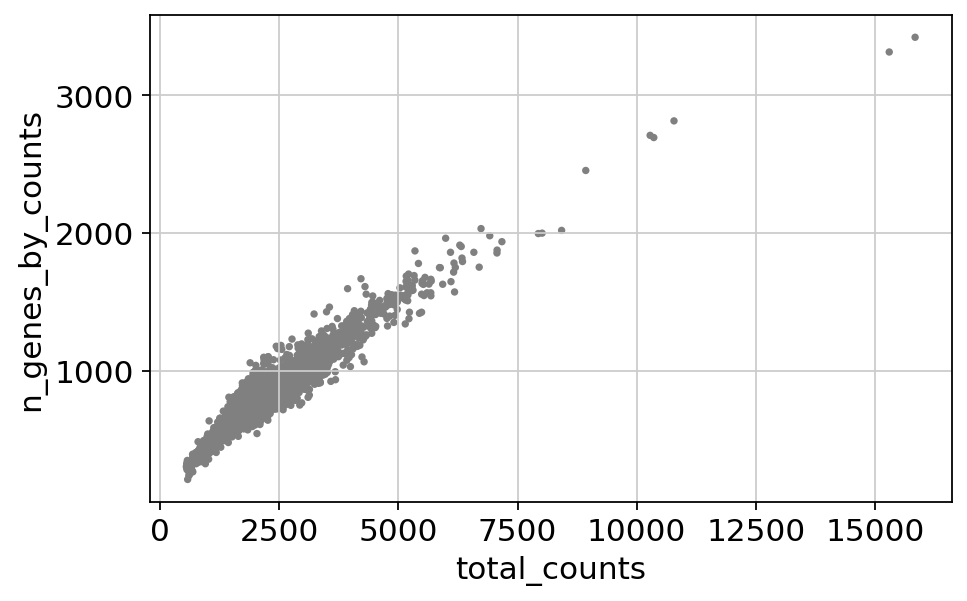

Scatter plots saved.


In [8]:
# Scatter plots: total counts vs gene count, colored by % mito
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', save='_mt_scatter.png')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', save='_genes_scatter.png')
print('Scatter plots saved.')

## Step 4 — Filter Low-Quality Cells and Genes

This code applies standard quality control filtering to your dataset by removing low-quality cells (those with too few/many genes or high mitochondrial content) and uninformative genes (those detected in very few cells). It provides a summary of the reduction in cell and gene counts, confirming how much "noise" was removed to improve the accuracy of your downstream analysis

In [9]:
print(f'Before filtering: {adata.n_obs} cells, {adata.n_vars} genes')

# Filter cells: keep cells with at least 200 and at most 2500 genes detected
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_cells(adata, max_genes=2500)

# Filter genes: keep genes detected in at least 3 cells
sc.pp.filter_genes(adata, min_cells=3)

# Filter out cells with high mitochondrial read percentage (dying cells)
adata = adata[adata.obs.pct_counts_mt < 5, :]

print(f'After filtering:  {adata.n_obs} cells, {adata.n_vars} genes')

Before filtering: 2700 cells, 32738 genes
filtered out 5 cells that have more than 2500 genes expressed
filtered out 19065 genes that are detected in less than 3 cells
After filtering:  2638 cells, 13673 genes


## Step 5 — Normalize Total Counts per Cell

This code performs Library Size Normalization (also called Counts Per Million, or CPM), which accounts for the variation in the total number of reads sequenced across different cells. By scaling every cell to a common target_sum of 10,000, it ensures that gene expression values are comparable, preventing cells with higher read depths from appearing more "active" simply due to technical sequencing differences.

In [10]:
# Normalize each cell to have 10,000 total counts (library size normalization)
sc.pp.normalize_total(adata, target_sum=1e4)
print('Normalization complete. Each cell now sums to 10,000 counts.')

normalizing counts per cell
    finished (0:00:05)
Normalization complete. Each cell now sums to 10,000 counts.


## Step 6 — Log-Transform

This code applies a log-transformation—specifically $log(x + 1)$—to your normalized data. This step compresses the dynamic range of gene expression, stabilizing the variance and making the data distribution more suitable for linear statistical methods. Storing this in adata.raw ensures you maintain the full, processed expression values for accurate differential expression testing later, even if you perform further scaling or subsetting on the main adata object.

In [11]:
# Log1p transform: log(x + 1)
sc.pp.log1p(adata)

# Save the raw (normalized + log) counts for downstream differential expression
adata.raw = adata
print('Log1p transformation complete. Raw counts saved to adata.raw.')

Log1p transformation complete. Raw counts saved to adata.raw.


## Step 7 — Identify Highly Variable Genes (HVGs)

This code identifies highly variable genes (HVGs)—the genes that show the most biological variation across your cell population—and filters your dataset to keep only these informative genes. By focusing on genes with high dispersion, you effectively filter out noise, which significantly improves the computational efficiency and accuracy of downstream dimensionality reduction and clustering.

extracting highly variable genes
    finished (0:00:03)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


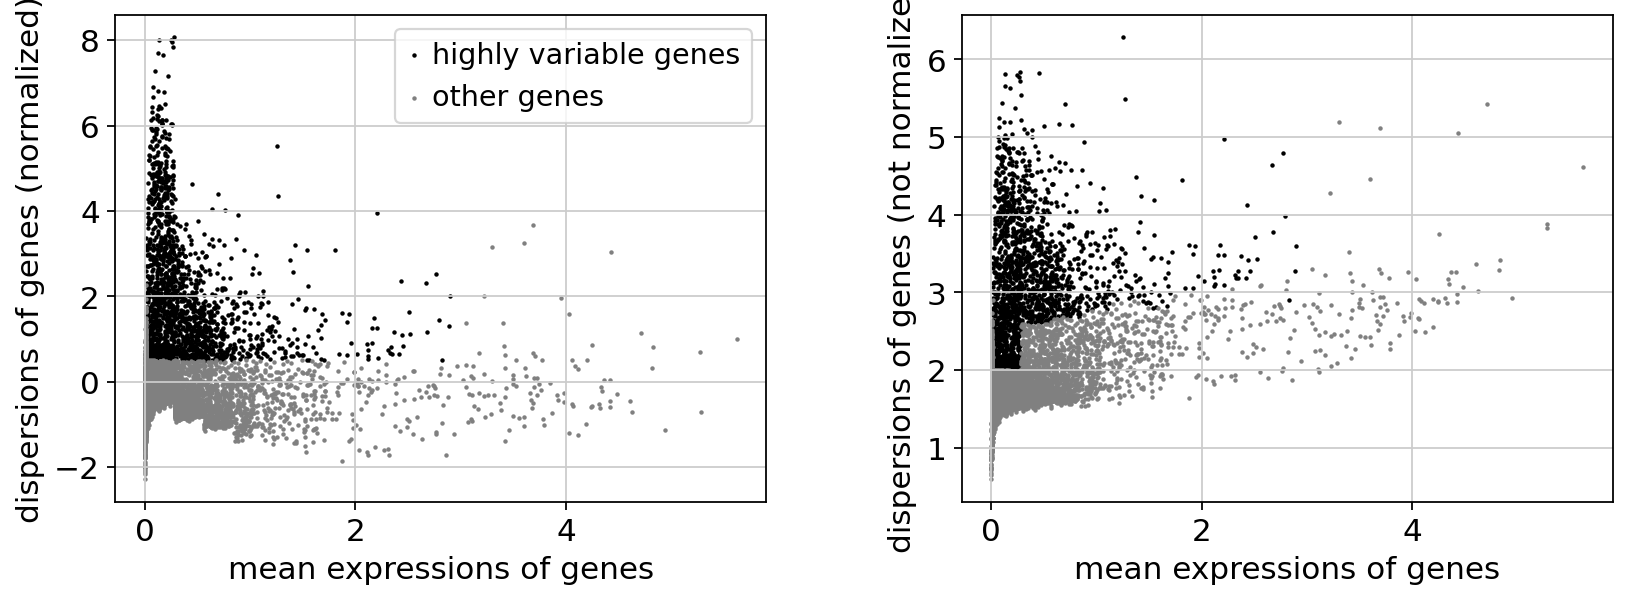

Number of highly variable genes: 1830
AnnData after HVG subset: (2638, 1830)


In [12]:
sc.pp.highly_variable_genes(
    adata,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)

sc.pl.highly_variable_genes(adata, save='_hvg.png')

print(f'Number of highly variable genes: {adata.var.highly_variable.sum()}')

# Subset to HVGs only
adata = adata[:, adata.var.highly_variable]
print(f'AnnData after HVG subset: {adata.shape}')

## Step 8 — Scale Data

This code performs z-score scaling on your data, ensuring each gene has a mean of zero and a variance of one across all cells. Clipping the values at 10 prevents extreme outliers from disproportionately influencing downstream algorithms like Principal Component Analysis (PCA).

In [13]:
# Scale to unit variance and zero mean (clip values at max 10)
sc.pp.scale(adata, max_value=10)
print('Data scaled to zero mean and unit variance.')

Data scaled to zero mean and unit variance.


## Step 9 — Principal Component Analysis (PCA)

This code performs Principal Component Analysis (PCA) to reduce your high-dimensional gene expression data into a smaller set of principal components that capture the most significant biological variation. It then plots the variance ratio for each component, which helps you determine how many PCs are needed to retain enough information for downstream steps like clustering.

computing PCA
    with n_comps=50
    finished (0:00:04)


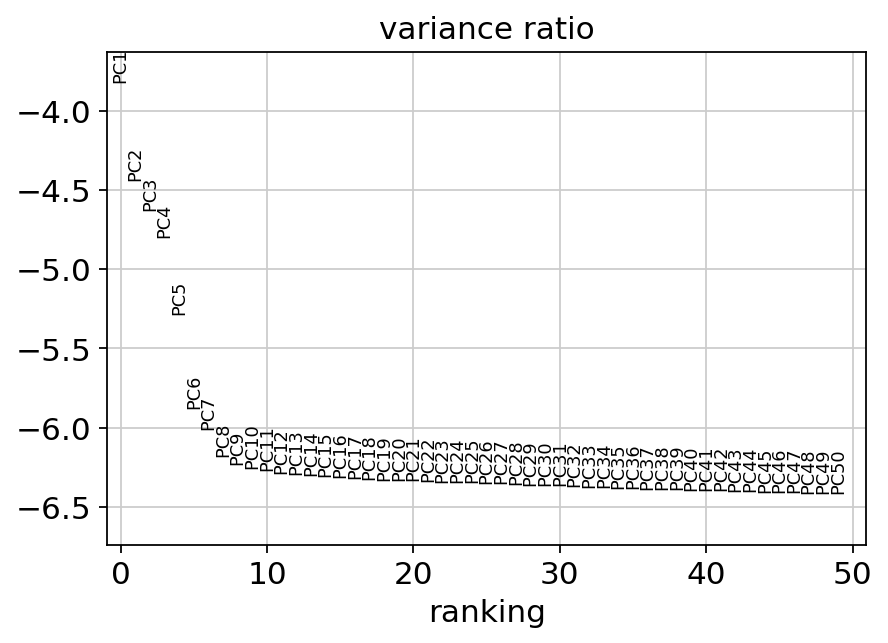

PCA complete.
PCA embedding shape: (2638, 50)


In [14]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50, save='_pca_variance.png')

print('PCA complete.')
print(f'PCA embedding shape: {adata.obsm["X_pca"].shape}')

## Step 10 — Save Pre-processed Data

In [15]:
output_path = 'pbmc3k_preprocessed.h5ad'
adata.write_h5ad(output_path)
print(f'Pre-processed AnnData saved to: {output_path}')
print('\nFinal AnnData summary:')
print(adata)

Pre-processed AnnData saved to: pbmc3k_preprocessed.h5ad

Final AnnData summary:
AnnData object with n_obs × n_vars = 2638 × 1830
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'


---
## Summary

| Step | Input | Output |
|---|---|---|
| Raw data | 2,700 cells × 32,738 genes | — |
| After QC filter | ~2,638 cells | low-quality cells removed |
| After gene filter | ~13,714 genes | rare genes removed |
| After HVG selection | ~1,838 HVGs | only informative genes kept |
| Output file | `pbmc3k_preprocessed.h5ad` | ready for clustering |

The pre-processed data is now ready for **Task 2: Basic scRNA-seq Tutorial** (clustering, UMAP, marker genes).